In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("/Users/fesavaskurt/Python&ML/Kodlarım/Python/datasets/ML Datasets/12-health_risk_classification.csv")

In [3]:
df.head()

,bmi_score,blood_pressure_variation,activity_level_index,high_risk_flag
0,0.564223,0.652825,1.262925,1
1,-1.692569,2.981229,-0.180331,1
2,0.770383,0.400475,1.365806,1
3,2.135007,0.150832,3.084596,0
4,0.360342,1.026132,1.251574,1


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 4 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   bmi_score                 1000 non-null   float64
 1   blood_pressure_variation  1000 non-null   float64
 2   activity_level_index      1000 non-null   float64
 3   high_risk_flag            1000 non-null   int64  
dtypes: float64(3), int64(1)
memory usage: 31.4 KB


In [7]:
df.describe()

,bmi_score,blood_pressure_variation,activity_level_index,high_risk_flag
count,1000.000000,1000.000000,1000.000000,1000.000000
mean,-0.023702,0.016769,-0.020771,0.498000
std,1.203694,1.268761,1.392738,0.500246
min,-4.743951,-2.587178,-4.999018,0.000000
25%,-0.796655,-0.981320,-1.057938,0.000000
50%,0.142105,-0.317137,0.204506,0.000000
75%,0.956225,1.017388,1.061181,1.000000
max,2.321480,3.954873,3.477210,1.000000


In [8]:
df.shape

(1000, 4)

In [9]:
df.isnull().sum()

bmi_score                   0
blood_pressure_variation    0
activity_level_index        0
high_risk_flag              0
dtype: int64

In [11]:
df["high_risk_flag"].value_counts()

high_risk_flag
0    502
1    498
Name: count, dtype: int64

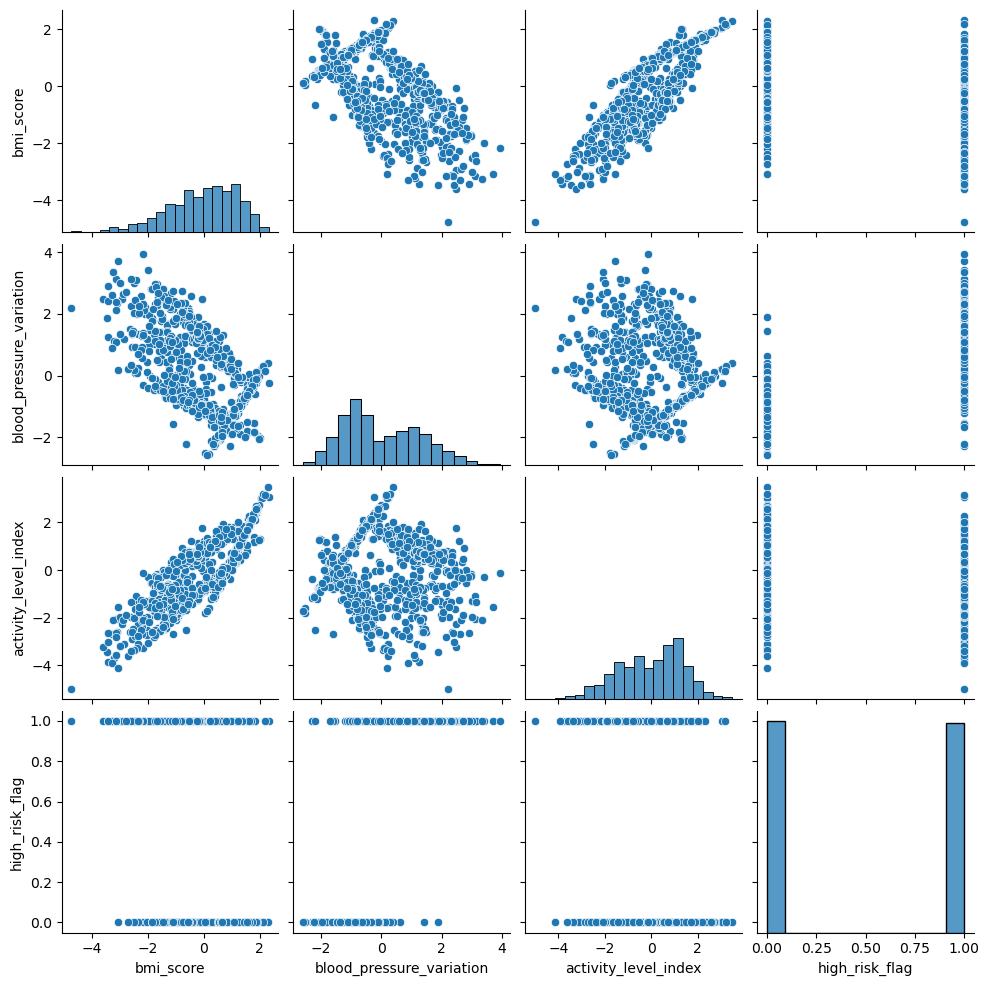

In [12]:
sns.pairplot(df)

<Axes: >

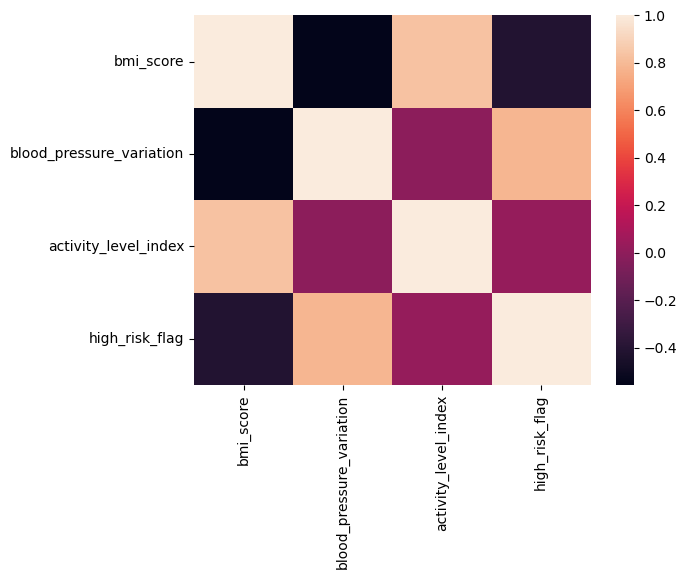

In [13]:
sns.heatmap(df.corr())

In [15]:
X = df.drop(columns= ["high_risk_flag"])
y = df["high_risk_flag"]

In [16]:
from sklearn.model_selection import train_test_split

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, random_state= 42, test_size= 0.2
)

In [18]:
from sklearn.preprocessing import StandardScaler

In [19]:
scaler = StandardScaler()

In [20]:
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [21]:
from sklearn.neighbors import KNeighborsClassifier

In [22]:
knn = KNeighborsClassifier()

In [23]:
knn.fit(X_train, y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [24]:
y_pred = knn.predict(X_test)

In [25]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [43]:
print("score: ", accuracy_score(y_pred, y_test))
print("matrix: ", confusion_matrix(y_pred, y_test))
print("classification: ", classification_report(y_pred, y_test))

score:  0.955
matrix:  [[103   9]
 [  0  88]]
classification:                precision    recall  f1-score   support

           0       1.00      0.92      0.96       112
           1       0.91      1.00      0.95        88

    accuracy                           0.95       200
   macro avg       0.95      0.96      0.95       200
weighted avg       0.96      0.95      0.96       200



In [27]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold

In [29]:
list = list(range(1,31))

In [31]:
params = dict(n_neighbors = list)

In [33]:
grid = GridSearchCV(estimator= knn, param_grid= params, cv = 5)

In [34]:
grid.fit(X_train, y_train)

,estimator,KNeighborsClassifier()
,param_grid,"{'n_neighbors': [1, 2, ...]}"
,scoring,None
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_neighbors,8


In [35]:
y_pred_neighbors = grid.predict(X_test)

In [37]:
grid.best_params_

{'n_neighbors': 8}

In [38]:
grid.best_score_

np.float64(0.9512500000000002)

In [39]:
from sklearn.linear_model import LogisticRegression

In [40]:
logistic = LogisticRegression()

In [41]:
logistic.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [42]:
y_pred_log = logistic.predict(X_test)

In [44]:
print("score: ", accuracy_score(y_pred_log, y_test))
print("matrix: ", confusion_matrix(y_pred_log, y_test))
print("classification: ", classification_report(y_pred_log, y_test))

score:  0.945
matrix:  [[99  7]
 [ 4 90]]
classification:                precision    recall  f1-score   support

           0       0.96      0.93      0.95       106
           1       0.93      0.96      0.94        94

    accuracy                           0.94       200
   macro avg       0.94      0.95      0.94       200
weighted avg       0.95      0.94      0.95       200

